In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import colorcet as cc
from scipy import stats

import matplotlib
import matplotlib.font_manager as fm
font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica.ttf'
fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = 'Helvetica'

title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
title_font = fm.FontProperties(fname=title_font_path)

In [ ]:
data = np.load('data/A_reduced.npz')

In [4]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
# extract each element across years
A11 = [ data[str(y)][0,0] for y in years ]
A12 = [ data[str(y)][0,1] for y in years ]
A21 = [ data[str(y)][1,0] for y in years ]
A22 = [ data[str(y)][1,1] for y in years ]

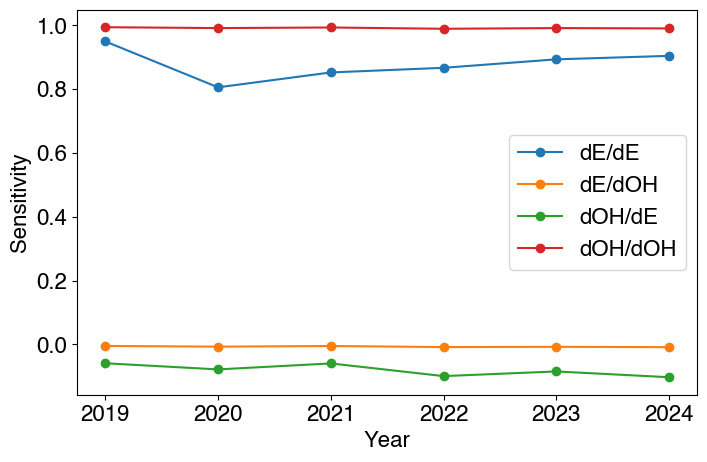

In [6]:
fig = plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size': 16})
plt.plot(years, A11, marker='o', label='dE/dE')
plt.plot(years, A12, marker='o', label='dE/dOH')
plt.plot(years, A21, marker='o', label='dOH/dE')
plt.plot(years, A22, marker='o', label='dOH/dOH')
plt.xlabel('Year')
plt.ylabel('Sensitivity')
plt.legend()
plt.show()

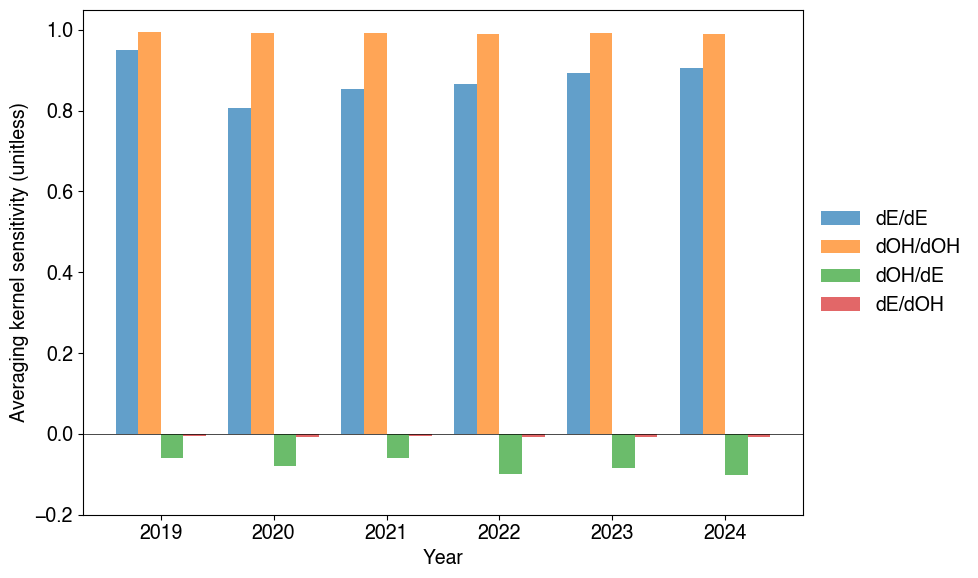

In [18]:
# compute x positions and bar width
x = np.arange(len(years))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))
plt.rcParams.update({'font.size': 14})

# plot each bar group
ax.bar(x - 1.5*width, A11, width, label='dE/dE', alpha=0.7)
ax.bar(x - 0.5*width, A22, width, label='dOH/dOH', alpha=0.7)
ax.bar(x + 0.5*width, A21, width, label='dOH/dE', alpha=0.7)
ax.bar(x + 1.5*width, A12, width, label='dE/dOH', alpha=0.7)

ax.axhline(0, color='black', linestyle='-', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_xlabel('Year')
ax.set_ylabel('Averaging kernel sensitivity (unitless)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_ylim(-0.2,)

plt.tight_layout()
plt.show()